In [70]:
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [71]:
!pip install wordcloud

In [72]:
data = pd.read_csv("/Users/namratabhoyar/Downloads/_chat.txt",sep="\t", on_bad_lines='skip')

In [73]:
data.head()

,"[07.10.25, 1:44:51 PM] Data Science 2025: ‎Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them."
0,"[07.10.25, 1:44:50 PM] ‎You: ‎‎You created thi..."
1,"[07.10.25, 1:44:51 PM] Vikrant Singh Thakur: ‎..."
2,"[07.10.25, 1:45:09 PM] ‎You: ‎‎You changed the..."
3,"[07.10.25, 1:45:19 PM] Martin Bratoi: ‎Martin ..."
4,"[07.10.25, 1:45:37 PM] ~ Shruti Bhandari: ‎~ S..."


In [74]:
data.shape

(507, 1)

In [75]:
def get_message(text):
    parts = str(text).split('] ', 1)
    if len(parts) > 1:
        msg = parts[1].split(': ', 1)
        return msg[1] if len(msg) > 1 else None
    return None

data['message'] = data[data.columns[0]].apply(get_message)
data = data[data['message'].notna()].copy()
print(f"Total messages: {len(data)}")
data.head()

Total messages: 393


,"[07.10.25, 1:44:51 PM] Data Science 2025: ‎Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them.",message
0,"[07.10.25, 1:44:50 PM] ‎You: ‎‎You created thi...",‎‎You created this group
1,"[07.10.25, 1:44:51 PM] Vikrant Singh Thakur: ‎...",‎Vikrant Singh Thakur was added
2,"[07.10.25, 1:45:09 PM] ‎You: ‎‎You changed the...",‎‎You changed the group name to “Data Science ...
3,"[07.10.25, 1:45:19 PM] Martin Bratoi: ‎Martin ...",‎Martin Bratoi joined using a group link.
4,"[07.10.25, 1:45:37 PM] ~ Shruti Bhandari: ‎~ S...",‎~ Shruti Bhandari joined using a group link.


In [76]:
# Keep only the message column
data = data[['message']].copy()

# Remove empty rows
data = data[data['message'].notna()]

print(f"Total messages: {len(data)}")
print("\nFirst 5 messages:")
print(data['message'].head())

Total messages: 393

First 5 messages:
0                             ‎‎You created this group
1                      ‎Vikrant Singh Thakur was added
2    ‎‎You changed the group name to “Data Science ...
3            ‎Martin Bratoi joined using a group link.
4        ‎~ Shruti Bhandari joined using a group link.
Name: message, dtype: object


In [77]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['cleaned'] = data['message'].apply(clean)

print("Cleaned text")
print("Before:", data['message'].iloc[10])
print("After: ", data['cleaned'].iloc[10])

Cleaned text
Before: Join my WhatsApp group. https://chat.whatsapp.com/GfTCCYczmkS8F7Y2SzsdzI?mode=ems_qr_t ‎image omitted
After:  join my whatsapp group httpschatwhatsappcomgftccyczmksfyszsdzimodeemsqrt image omitted


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/namratabhoyar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/namratabhoyar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/namratabhoyar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [78]:
#TOKENIZE
data['tokens'] = data['cleaned'].apply(word_tokenize)

print("Tokenized")
print("Tokens:", data['tokens'].iloc[10])
print()

Tokenized
Tokens: ['join', 'my', 'whatsapp', 'group', 'httpschatwhatsappcomgftccyczmksfyszsdzimodeemsqrt', 'image', 'omitted']



In [79]:
#REMOVE STOPWORDS
stop_words = set(stopwords.words('english'))

def remove_stop(tokens):
    return [w for w in tokens if w not in stop_words and len(w) > 2]

data['no_stop'] = data['tokens'].apply(remove_stop)

print("Removed stopwords")
print("Before:", data['tokens'].iloc[10])
print("After: ", data['no_stop'].iloc[10])
print()

Removed stopwords
Before: ['join', 'my', 'whatsapp', 'group', 'httpschatwhatsappcomgftccyczmksfyszsdzimodeemsqrt', 'image', 'omitted']
After:  ['join', 'whatsapp', 'group', 'httpschatwhatsappcomgftccyczmksfyszsdzimodeemsqrt', 'image', 'omitted']



In [80]:
#LEMMATIZE
lemma = WordNetLemmatizer()

def lemmatize_words(tokens):
    return [lemma.lemmatize(w) for w in tokens]

data['lemma'] = data['no_stop'].apply(lemmatize_words)

print("Lemmatized")
print("Before:", data['no_stop'].iloc[10])
print("After: ", data['lemma'].iloc[10])
print()

Lemmatized
Before: ['join', 'whatsapp', 'group', 'httpschatwhatsappcomgftccyczmksfyszsdzimodeemsqrt', 'image', 'omitted']
After:  ['join', 'whatsapp', 'group', 'httpschatwhatsappcomgftccyczmksfyszsdzimodeemsqrt', 'image', 'omitted']



In [81]:
#GET WORD FREQUENCY
all_words = []
for words in data['lemma']:
    all_words.extend(words)

freq = Counter(all_words)
top_20 = freq.most_common(20)

print("Word Frequency")
print("\nTOP 20 MOST COMMON WORDS:")
print("-" * 40)
for i, (word, count) in enumerate(top_20, 1):
    print(f"{i:2d}. {word:20s} → {count} times")
print()

Word Frequency

TOP 20 MOST COMMON WORDS:
----------------------------------------
 1. added                → 57 times
 2. group                → 56 times
 3. link                 → 49 times
 4. using                → 44 times
 5. joined               → 42 times
 6. omitted              → 31 times
 7. image                → 24 times
 8. merry                → 22 times
 9. christmas            → 22 times
10. new                  → 20 times
11. guy                  → 18 times
12. lecture              → 15 times
13. class                → 14 times
14. message              → 14 times
15. year                 → 13 times
16. anyone               → 12 times
17. today                → 11 times
18. happy                → 11 times
19. yes                  → 10 times
20. team                 → 10 times



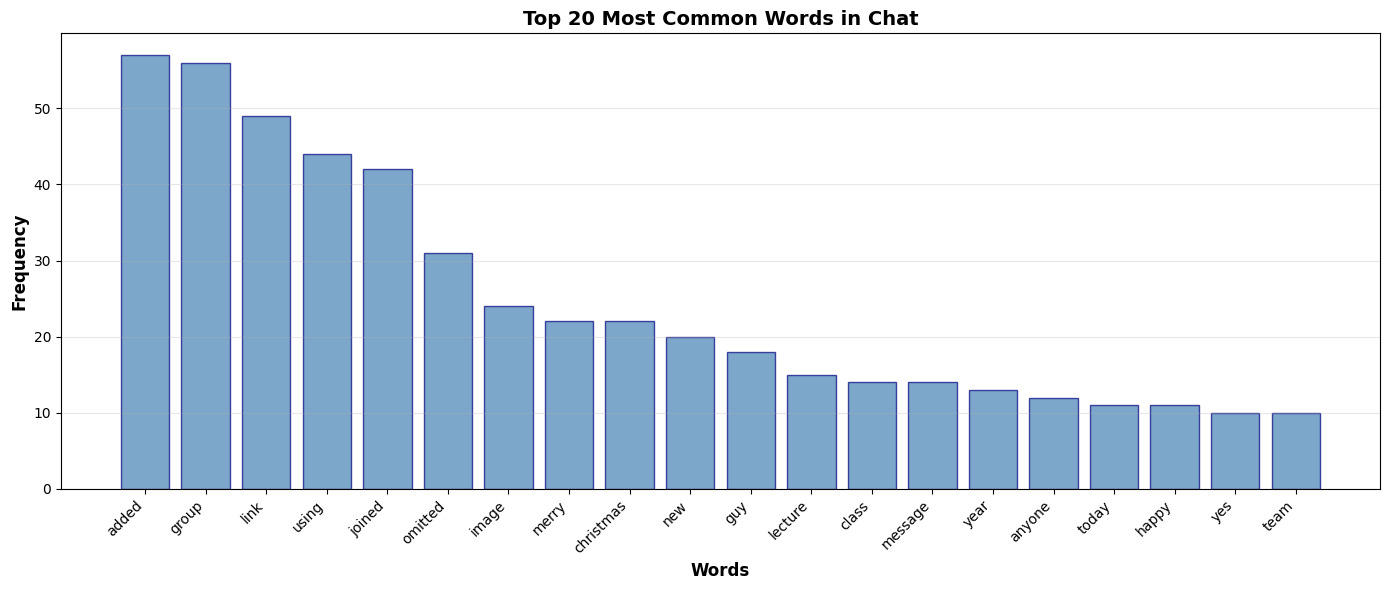

In [86]:
#VISUALIZE
words = [w for w, c in top_20]
counts = [c for w, c in top_20]

plt.figure(figsize=(14, 6))
plt.bar(words, counts, color='steelblue', edgecolor='navy', alpha=0.7)
plt.xlabel('Words', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Common Words in Chat', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('word_frequency.png', dpi=300)
plt.show()
print()

In [87]:
#SUMMARY
print("SUMMARY")
print(f"Total messages: {len(data)}")
print(f"Total words: {len(all_words)}")
print(f"Unique words: {len(freq)}")
print(f"Avg words/message: {len(all_words)/len(data):.2f}")

SUMMARY
Total messages: 393
Total words: 1497
Unique words: 585
Avg words/message: 3.81


Total words for word cloud: 1497



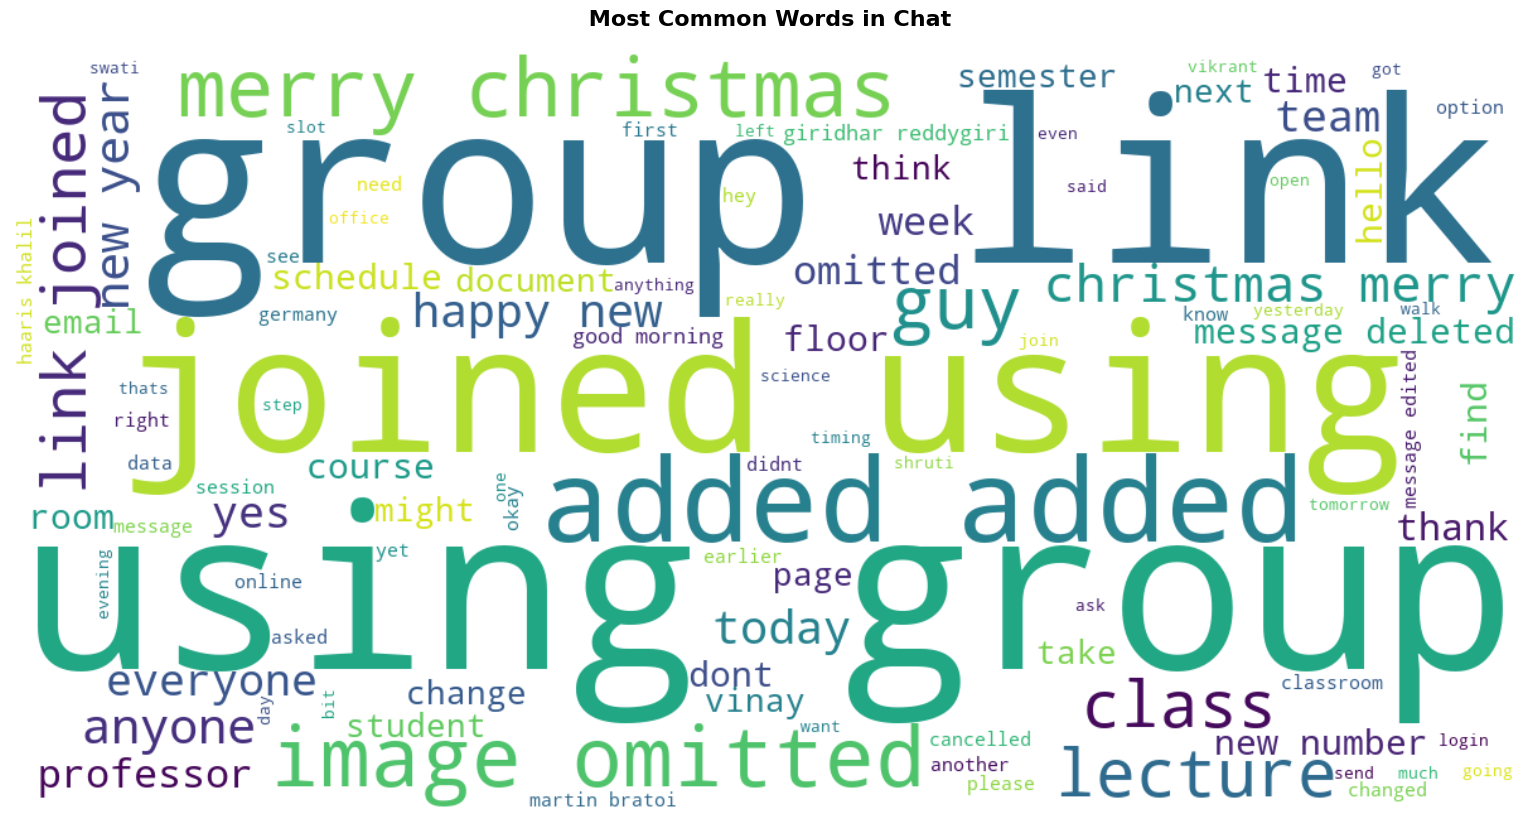

Word Cloud created!
Bigger words = More frequent in your chat


In [88]:
#WORD CLOUD
# Combine all lemmatized words into one string
all_words_text = ' '.join([word for words_list in data['lemma'] for word in words_list])

print(f"Total words for word cloud: {len(all_words_text.split())}")
print()
# Create word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10
).generate(all_words_text)

# Display
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(' Most Common Words in Chat', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout(pad=0)
plt.savefig('wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

print("Word Cloud created!")
print("Bigger words = More frequent in your chat")